# 01 — Descrição do Dataset

## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Descrever as características do dataset, incluindo domínio, dimensão, tipos de variáveis e qualidade dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tema visual
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print('Setup completo!')

Setup completo!


In [ ]:
# Carregamento do Dataset
FILE_PATH = '../data/instagram_usage_lifestyle.csv'

print('A carregar dataset...')
df = pd.read_csv(FILE_PATH)

# Guardar apenas os primeiros 300.000 utilizadores
df = df.head(300000)

print(f'Carregado! {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head(3)

A carregar dataset...
Carregado! 300,000 linhas × 58 colunas


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67


In [ ]:
# Ficha Técnica
print('=' * 60)
print('   FICHA TÉCNICA DO DATASET')
print('=' * 60)
print(f'  Domínio      : Redes Sociais & Comportamento Digital')
print(f'  Fonte        : Kaggle — rockyt07')
print(f'  Ficheiro     : instagram_usage_lifestyle.csv')
print(f'  Utilizadores : {df.shape[0]:>12,}')
print(f'  Variáveis    : {df.shape[1]:>12}')
print(f'  Tipo         : 100% Sintético')
print(f'  Período      : Instagram 2025–2026')
print(f'  Licença      : CC0 Public Domain')
print('=' * 60)

# Tipos de dados
print('\nDistribuição de tipos de variáveis:')
for dtype, count in df.dtypes.value_counts().items():
    pct = count / df.shape[1] * 100
    print(f'   {str(dtype):<12} → {count:>2} colunas ({pct:.0f}%)')

   FICHA TÉCNICA DO DATASET
  Domínio      : Redes Sociais & Comportamento Digital
  Fonte        : Kaggle — rockyt07
  Ficheiro     : instagram_usage_lifestyle.csv
  Utilizadores :      300,000
  Variáveis    :           58
  Tipo         : 100% Sintético
  Período      : Instagram 2025–2026
  Licença      : CC0 Public Domain

Distribuição de tipos de variáveis:
   int64        → 29 colunas (50%)
   object       → 20 colunas (34%)
   float64      →  9 colunas (16%)


In [ ]:
# Qualidade dos Dados

# Valores em falta
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
total_nulls = missing.sum()

print(f'Total de valores em falta: {total_nulls}')
if total_nulls == 0:
    print('   Dataset sem valores em falta!')
else:
    print('   Colunas com valores em falta:')
    for col in missing[missing > 0].index:
        print(f'   • {col}: {missing[col]} ({missing_pct[col]}%)')

# Duplicados
dups = df.duplicated().sum()
print(f'\nRegistos duplicados: {dups}',
      '' if dups == 0 else 'Remover!')

# Resumo geral
print(f'\nResumo de qualidade:')
print(f'   Completude : {(1 - total_nulls/(df.shape[0]*df.shape[1]))*100:.4f}%')
print(f'   Unicidade  : {(1 - dups/df.shape[0])*100:.4f}%')

Total de valores em falta: 0
   Dataset sem valores em falta!

Registos duplicados: 0 

Resumo de qualidade:
   Completude : 100.0000%
   Unicidade  : 100.0000%


In [ ]:
# Grupos de Variáveis

GROUPS = {
    'Demográficas': [
        'age','gender','country','urban_rural','income_level',
        'employment_status','education_level','relationship_status','has_children'
    ],
    'Saúde & Lifestyle': [
        'exercise_hours_per_week','sleep_hours_per_night','diet_quality',
        'smoking','alcohol_frequency','perceived_stress_score',
        'self_reported_happiness','body_mass_index',
        'blood_pressure_systolic','blood_pressure_diastolic','daily_steps_count'
    ],
    'Hábitos Semanais': [
        'weekly_work_hours','hobbies_count','social_events_per_month',
        'books_read_per_year','volunteer_hours_per_month','travel_frequency_per_year'
    ],
    'Uso do Instagram': [
        'daily_active_minutes_instagram','sessions_per_day','posts_created_per_week',
        'reels_watched_per_day','stories_viewed_per_day','likes_given_per_day',
        'comments_written_per_day','dms_sent_per_week','followers_count',
        'following_count','user_engagement_score','time_on_feed_per_day',
        'time_on_reels_per_day','time_on_explore_per_day','time_on_messages_per_day'
    ],
}

VAR_TIPOS = {
    'user_id': 'Quant. Discreta', 'app_name': 'Qual. Nominal',
    'age': 'Quant. Contínua', 'gender': 'Qual. Nominal',
    'country': 'Qual. Nominal', 'urban_rural': 'Qual. Nominal',
    'income_level': 'Qual. Ordinal', 'employment_status': 'Qual. Nominal',
    'education_level': 'Qual. Ordinal', 'relationship_status': 'Qual. Nominal',
    'has_children': 'Booleana', 'exercise_hours_per_week': 'Quant. Contínua',
    'sleep_hours_per_night': 'Quant. Contínua', 'diet_quality': 'Qual. Ordinal',
    'smoking': 'Booleana', 'alcohol_frequency': 'Qual. Ordinal',
    'perceived_stress_score': 'Quant. Contínua', 'self_reported_happiness': 'Quant. Discreta',
    'body_mass_index': 'Quant. Contínua', 'blood_pressure_systolic': 'Quant. Contínua',
    'blood_pressure_diastolic': 'Quant. Contínua', 'daily_steps_count': 'Quant. Contínua',
    'weekly_work_hours': 'Quant. Contínua', 'hobbies_count': 'Quant. Discreta',
    'social_events_per_month': 'Quant. Discreta', 'books_read_per_year': 'Quant. Discreta',
    'volunteer_hours_per_month': 'Quant. Contínua', 'travel_frequency_per_year': 'Quant. Discreta',
    'daily_active_minutes_instagram': 'Quant. Contínua', 'sessions_per_day': 'Quant. Discreta',
    'posts_created_per_week': 'Quant. Discreta', 'reels_watched_per_day': 'Quant. Contínua',
    'stories_viewed_per_day': 'Quant. Contínua', 'likes_given_per_day': 'Quant. Contínua',
    'comments_written_per_day': 'Quant. Discreta', 'dms_sent_per_week': 'Quant. Discreta',
    'dms_received_per_week': 'Quant. Discreta', 'ads_viewed_per_day': 'Quant. Discreta',
    'ads_clicked_per_day': 'Quant. Discreta', 'time_on_feed_per_day': 'Quant. Contínua',
    'time_on_explore_per_day': 'Quant. Contínua', 'time_on_messages_per_day': 'Quant. Contínua',
    'time_on_reels_per_day': 'Quant. Contínua', 'followers_count': 'Quant. Contínua',
    'following_count': 'Quant. Contínua', 'uses_premium_features': 'Booleana',
    'notification_response_rate': 'Quant. Contínua', 'account_creation_year': 'Quant. Discreta',
    'last_login_date': 'Qual. Nominal', 'average_session_length_minutes': 'Quant. Contínua',
    'content_type_preference': 'Qual. Nominal', 'preferred_content_theme': 'Qual. Nominal',
    'privacy_setting_level': 'Qual. Ordinal', 'two_factor_auth_enabled': 'Booleana',
    'biometric_login_used': 'Booleana', 'linked_accounts_count': 'Quant. Discreta',
    'subscription_status': 'Qual. Nominal', 'user_engagement_score': 'Quant. Contínua',
}

for grupo, cols in GROUPS.items():
    existentes = [c for c in cols if c in df.columns]
    print(f'\n{grupo} ({len(existentes)} variáveis)')
    print('─' * 55)
    for col in existentes:
        tipo = VAR_TIPOS.get(col, 'N/A')
        nunique = df[col].nunique()
        print(f'  • {col:<45} [{tipo}] — {nunique} únicos')


Demográficas (9 variáveis)
───────────────────────────────────────────────────────
  • age                                           [Quant. Contínua] — 53 únicos
  • gender                                        [Qual. Nominal] — 4 únicos
  • country                                       [Qual. Nominal] — 10 únicos
  • urban_rural                                   [Qual. Nominal] — 3 únicos
  • income_level                                  [Qual. Ordinal] — 5 únicos
  • employment_status                             [Qual. Nominal] — 6 únicos
  • education_level                               [Qual. Ordinal] — 6 únicos
  • relationship_status                           [Qual. Nominal] — 5 únicos
  • has_children                                  [Booleana] — 2 únicos

Saúde & Lifestyle (11 variáveis)
───────────────────────────────────────────────────────
  • exercise_hours_per_week                       [Quant. Contínua] — 237 únicos
  • sleep_hours_per_night                         [Qu

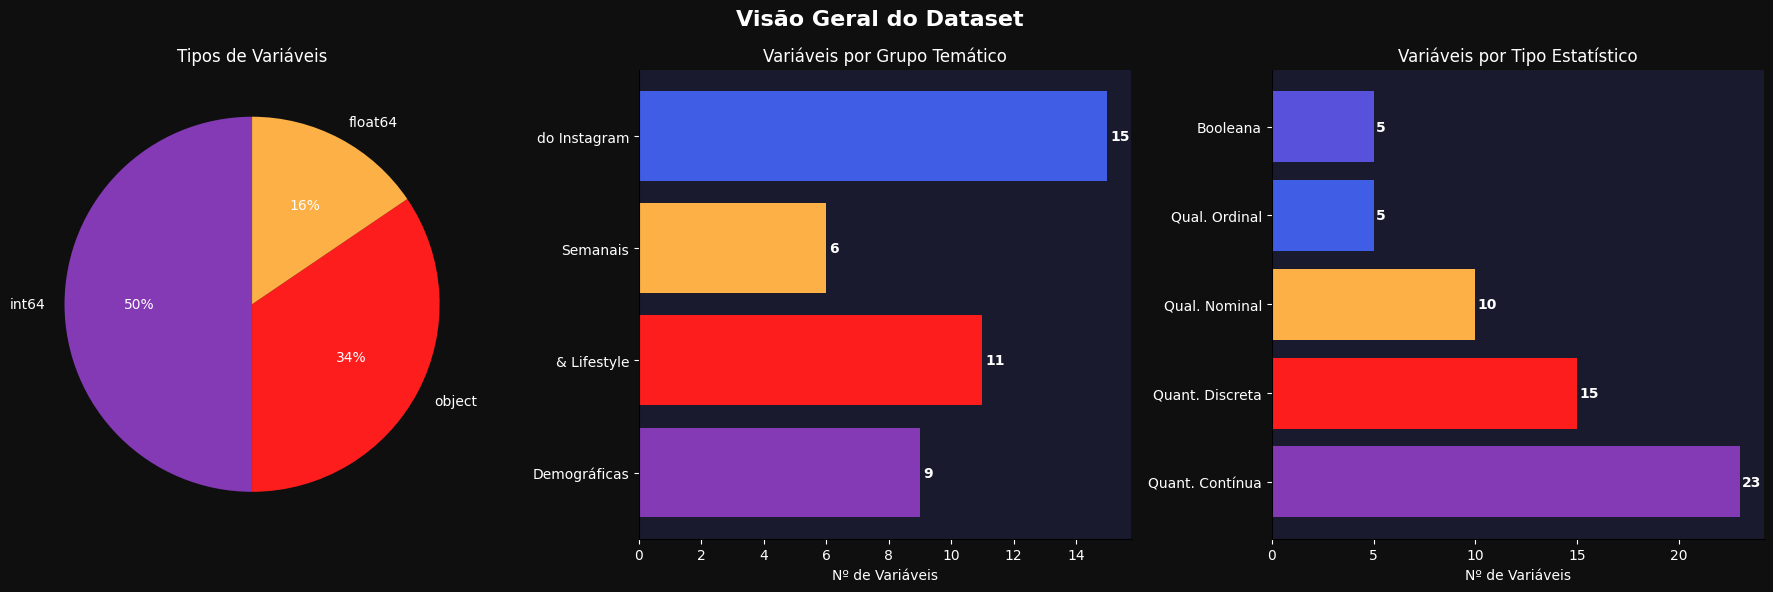

Guardado: fig_dataset_overview.png


In [ ]:
# Gráficos de Visão Geral

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Visão Geral do Dataset', fontsize=16, fontweight='bold')

# 1. Tipos de dados
dtype_counts = df.dtypes.astype(str).value_counts()
axes[0].pie(
    dtype_counts.values,
    labels=dtype_counts.index,
    colors=INSTA_COLORS[:len(dtype_counts)],
    autopct='%1.0f%%', startangle=90,
    textprops={'color': 'white'}
)
axes[0].set_title('Tipos de Variáveis', fontsize=12)

# 2. Variáveis por grupo
group_sizes = {
    g.split(' ', 1)[1] if ' ' in g else g: len([c for c in cols if c in df.columns])
    for g, cols in GROUPS.items()
}
bars = axes[1].barh(
    list(group_sizes.keys()),
    list(group_sizes.values()),
    color=INSTA_COLORS[:4]
)
axes[1].set_title('Variáveis por Grupo Temático', fontsize=12)
axes[1].set_xlabel('Nº de Variáveis')
for bar, val in zip(bars, group_sizes.values()):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', color='white', fontweight='bold')

# 3. Classificação por tipo
tipo_counts = pd.Series(VAR_TIPOS).value_counts()
bars2 = axes[2].barh(
    tipo_counts.index,
    tipo_counts.values,
    color=INSTA_COLORS[:len(tipo_counts)]
)
axes[2].set_title('Variáveis por Tipo Estatístico', fontsize=12)
axes[2].set_xlabel('Nº de Variáveis')
for bar, val in zip(bars2, tipo_counts.values):
    axes[2].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fig_dataset_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Guardado: fig_dataset_overview.png')

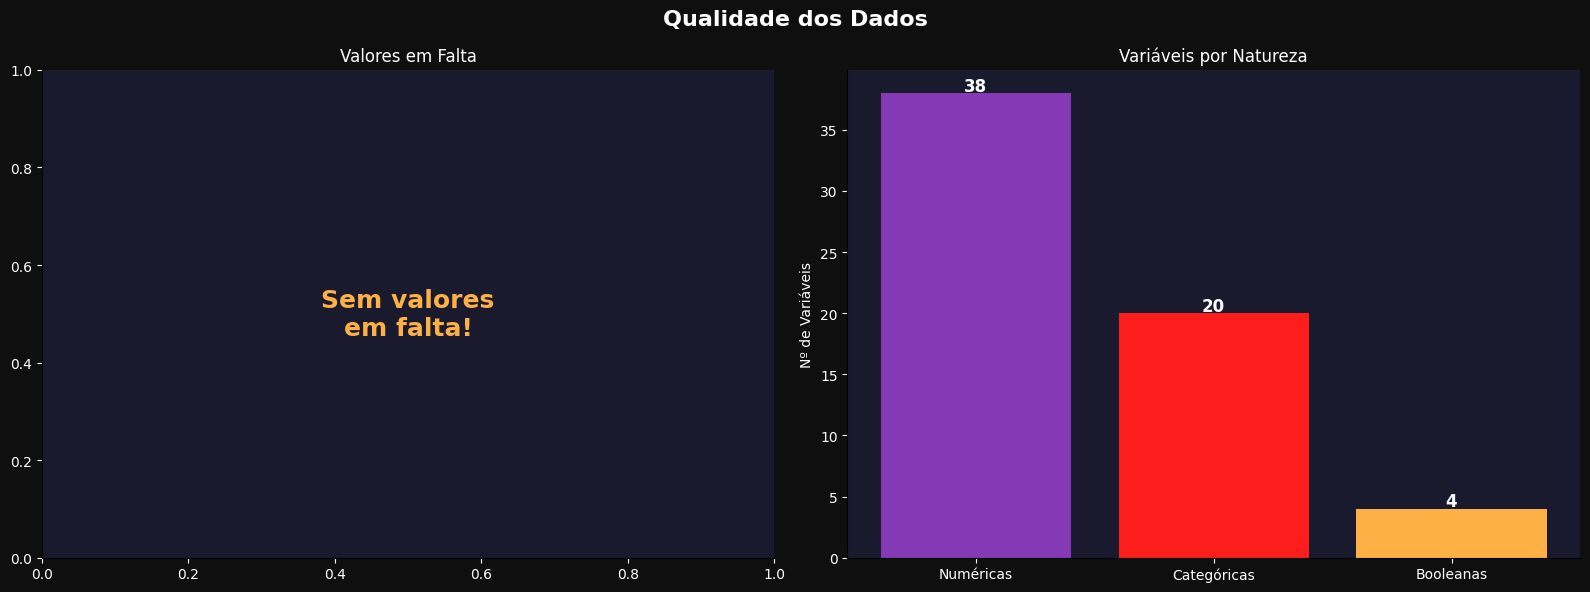

Guardado: fig_01_data_quality.png


In [ ]:
# Gráfico 2 — Qualidade dos Dados

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Qualidade dos Dados', fontsize=16, fontweight='bold')

# 1. Valores em falta por coluna
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) == 0:
    axes[0].text(0.5, 0.5, 'Sem valores\nem falta!',
                ha='center', va='center', fontsize=18,
                color='#fcb045', fontweight='bold',
                transform=axes[0].transAxes)
    axes[0].set_title('Valores em Falta', fontsize=12)
else:
    axes[0].barh(missing_data.index, missing_data.values, color=INSTA_COLORS[1])
    axes[0].set_title('Colunas com Valores em Falta', fontsize=12)
    axes[0].set_xlabel('Nº de Valores em Falta')

# 2. Distribuição de valores únicos por tipo
num_cols  = df.select_dtypes(include='number').columns
cat_cols  = df.select_dtypes(include='object').columns
bool_cols = [c for c in df.columns if df[c].nunique() == 2]

contagens = {
    'Numéricas': len(num_cols),
    'Categóricas': len(cat_cols),
    'Booleanas': len(bool_cols),
}
axes[1].bar(
    contagens.keys(),
    contagens.values(),
    color=INSTA_COLORS[:3]
)
axes[1].set_title('Variáveis por Natureza', fontsize=12)
axes[1].set_ylabel('Nº de Variáveis')
for i, (k, v) in enumerate(contagens.items()):
    axes[1].text(i, v + 0.2, str(v), ha='center',
                color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('fig_01_data_quality.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Guardado: fig_01_data_quality.png')

In [ ]:
# Exportação — Guardar Dicionário de Variáveis

# Cria tabela completa de variáveis para usar nos outros notebooks
var_info = pd.DataFrame([
    {
        'variavel': col,
        'tipo': VAR_TIPOS.get(col, 'N/A'),
        'dtype': str(df[col].dtype),
        'n_unicos': df[col].nunique(),
        'n_nulos': df[col].isnull().sum(),
    }
    for col in df.columns
])

var_info.to_csv('../data/variable_info.csv', index=False)
print('Dicionário de variáveis guardado: data/variable_info.csv')
print(f'\nNotebook 01 completo!')
print(f'   Próximo: 02_numeric_variables.ipynb')

Dicionário de variáveis guardado: data/variable_info.csv

Notebook 01 completo!
   Próximo: 02_numeric_variables.ipynb


# Análise Crítica

## Limitações do Dataset

O dataset utilizado neste estudo é completamente sintético, gerado artificialmente para simular dados de usuários do Instagram e seus hábitos de vida. Embora isso permita uma exploração controlada e livre de questões éticas relacionadas à privacidade de dados reais, apresenta limitações significativas:

- **Falta de Realismo**: Os dados não refletem comportamentos humanos autênticos, o que pode levar a conclusões que não se aplicam a populações reais. Por exemplo, correlações observadas podem ser artificiais devido aos algoritmos de geração de dados.

- **Ausência de Viéses Reais**: Em dados reais, fatores como viés de seleção (apenas usuários ativos reportam dados) ou viés de resposta não estão presentes, tornando o dataset "perfeito" demais para estudos de qualidade de dados.

- **Dimensão Limitada**: Com 300.000 registros, o dataset é substancial, mas em cenários reais, datasets maiores ou com dados longitudinais seriam necessários para análises mais robustas.

## Implicações para o Estudo

A qualidade excepcional dos dados (sem valores em falta ou duplicados) facilita a análise, mas não prepara adequadamente para desafios comuns em ciência de dados aplicada. Recomenda-se validar os achados com dados reais quando possível, e considerar técnicas de imputação e limpeza de dados em estudos futuros.

As variáveis abrangem aspectos demográficos, de saúde e uso da plataforma, proporcionando uma base sólida para análises subsequentes. No entanto, a ausência de dados temporais impede estudos de causalidade ou evolução de comportamentos ao longo do tempo.